In [1]:
# Problem: K-Means clustering to segment customers based on behavior
# Dataset: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Step 1: Load the data
data = pd.read_csv('Mall_Customers.csv')
print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [5]:
# Step 2: Data Preprocessing
# Drop CustomerID as it is not useful for clustering.
data.drop('CustomerID', axis=1)

# Encode Gender, male - 0, female - 1
data['Genre'] = data['Genre'].map({'Male': 0, 'Female': 1})

# Handle missing value.
print(data.isnull().sum()) # We don't have any missing value.


CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [7]:
# Step 3: Create features for Cluster
X = data[['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]


In [8]:
# Step 4: Apply Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# Step 5: Apply Elbow method to find the optimal number of clusters (K)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

C:\Users\muhid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\muhid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\muhid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\muhid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

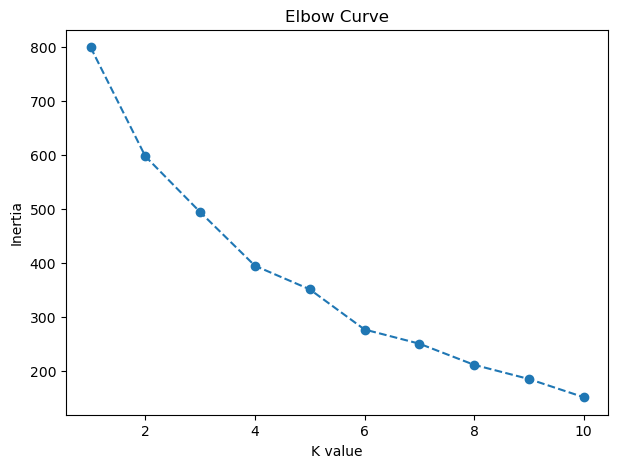

In [10]:
# Plot the Elbow curve
plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Curve')
plt.xlabel('K value')
plt.ylabel('Inertia')
plt.show()


In [11]:
# Step 6: Apply K Means on the optimal number of clusters (K = 4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init='auto')
y_kmeans = kmeans.fit_predict(X_scaled)

C:\Users\muhid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


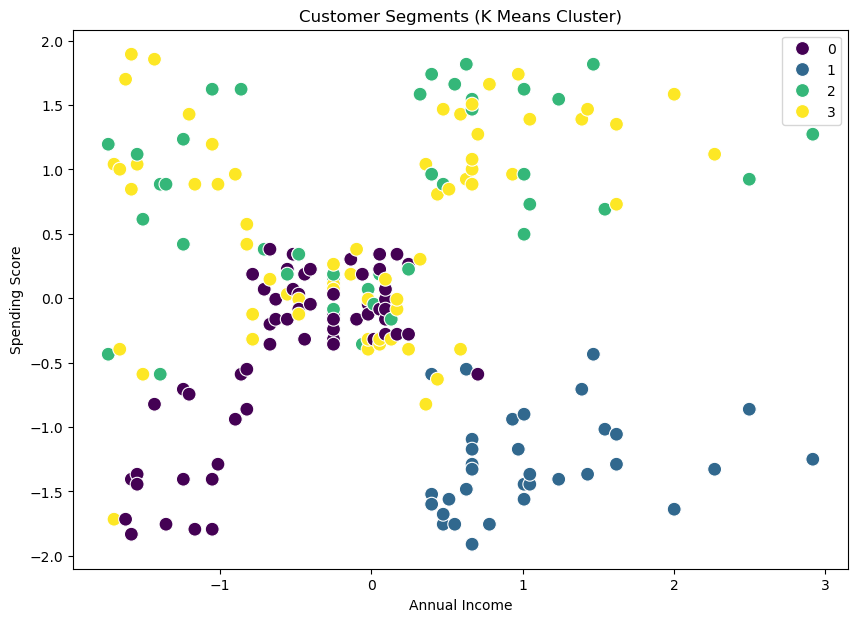

In [12]:
# Step 7: Visualize the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_scaled[:, 2], y=X_scaled[:, 3], hue=y_kmeans, palette="viridis", s=100)
# We are plotting the Annual Income (x-axis) against the Spending Score (y-axis) for each customer.
plt.title('Customer Segments (K Means Cluster)')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()